The telecom operator Interconnect would like to be able to forecast their churn of clients. If it's discovered that a user is planning to leave, they will be offered promotional codes and special plan options. Interconnect's marketing team has collected some of their clientele's personal data, including information about their plans and contracts.

The data consists of files obtained from different sources:

contract.csv — contract information personal.csv — the client's personal data internet.csv — information about Internet services phone.csv — information about telephone services In each file, the column customerID contains a unique code assigned to each client.

The contract information is valid as of February 1, 2020. If has a value in EndDate, client has left on that date. If no, means client is active.

The telecome operator Interconnect would like to forecast churn of thier clients The company wants to forecast which users are planning to leave TO ensure loyalty, those who are going to leave, will be offered with promotional codes and special plan options

Target feature: the 'EndDate' column equals 'No'.

Primary metric: AUC-ROC.

Additional metric: Accuracy.

Assessment criteria:

AUC-ROC < 0.75 — 0 SP 0.75 ≤ AUC-ROC < 0.81 — 4 SP 0.81 ≤ AUC-ROC < 0.85 — 4.5 SP 0.85 ≤ AUC-ROC < 0.87 — 5 SP 0.87 ≤ AUC-ROC < 0.88 — 5.5 SP AUC-ROC ≥ 0.88 — 6 SP



In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

In [91]:
contract_df = pd.read_csv('/datasets/final_provider/contract.csv')
personal_df = pd.read_csv('/datasets/final_provider/personal.csv')
internet_df = pd.read_csv('/datasets/final_provider/internet.csv')
phone_df = pd.read_csv('/datasets/final_provider/phone.csv')


In [92]:
print("===== contract_df =====")
print("Data shape:", contract_df.shape)
print("\nColumn names and types:")
display(contract_df.dtypes)

print("\nFirst few rows:")
display(contract_df.head())


===== contract_df =====
Data shape: (7043, 8)

Column names and types:


customerID           object
BeginDate            object
EndDate              object
Type                 object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
dtype: object


First few rows:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [93]:
contract_df['EndDate'].value_counts()

No                     5174
2019-11-01 00:00:00     485
2019-12-01 00:00:00     466
2020-01-01 00:00:00     460
2019-10-01 00:00:00     458
Name: EndDate, dtype: int64

In [94]:
total_clients = len(contract_df)
active_clients = 5174
churned_clients = 1869

print(f"Active clients: {active_clients/total_clients:.1%}")
print(f"Churned clients: {churned_clients/total_clients:.1%}")

Active clients: 73.5%
Churned clients: 26.5%


In [95]:
# Missing values
print("Missing values:")
print(contract_df.isnull().sum())

Missing values:
customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


In [96]:
print(contract_df.duplicated().sum())

0


In [97]:
# Explore categorical variables
print("Contract Types:")
print(contract_df['Type'].value_counts())
print("\nPayment Methods:")
print(contract_df['PaymentMethod'].value_counts())

Contract Types:
Month-to-month    3875
Two year          1695
One year          1473
Name: Type, dtype: int64

Payment Methods:
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: PaymentMethod, dtype: int64


In [98]:
# Churn rate by contract type
churn_by_contract = contract_df.groupby('Type')['EndDate'].apply(lambda x: (x != 'No').mean())
print("Churn rate by contract type:")
print(churn_by_contract.sort_values(ascending=False))

Churn rate by contract type:
Type
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: EndDate, dtype: float64


In [99]:
# Cross-tabulation of contract type and payment method
contract_payment_crosstab = pd.crosstab(contract_df['Type'], contract_df['PaymentMethod'], margins=True)
print("Contract Type vs Payment Method:")
print(contract_payment_crosstab)

Contract Type vs Payment Method:
PaymentMethod   Bank transfer (automatic)  Credit card (automatic)  \
Type                                                                 
Month-to-month                        589                      543   
One year                              391                      398   
Two year                              564                      581   
All                                  1544                     1522   

PaymentMethod   Electronic check  Mailed check   All  
Type                                                  
Month-to-month              1850           893  3875  
One year                     347           337  1473  
Two year                     168           382  1695  
All                         2365          1612  7043  


In [100]:
# Percentage breakdown within each contract type
contract_payment_pct = pd.crosstab(contract_df['Type'], contract_df['PaymentMethod'], normalize='index') * 100
print("\nPayment method preferences by contract type (%):")
print(contract_payment_pct.round(1))


Payment method preferences by contract type (%):
PaymentMethod   Bank transfer (automatic)  Credit card (automatic)  \
Type                                                                 
Month-to-month                       15.2                     14.0   
One year                             26.5                     27.0   
Two year                             33.3                     34.3   

PaymentMethod   Electronic check  Mailed check  
Type                                            
Month-to-month              47.7          23.0  
One year                    23.6          22.9  
Two year                     9.9          22.5  


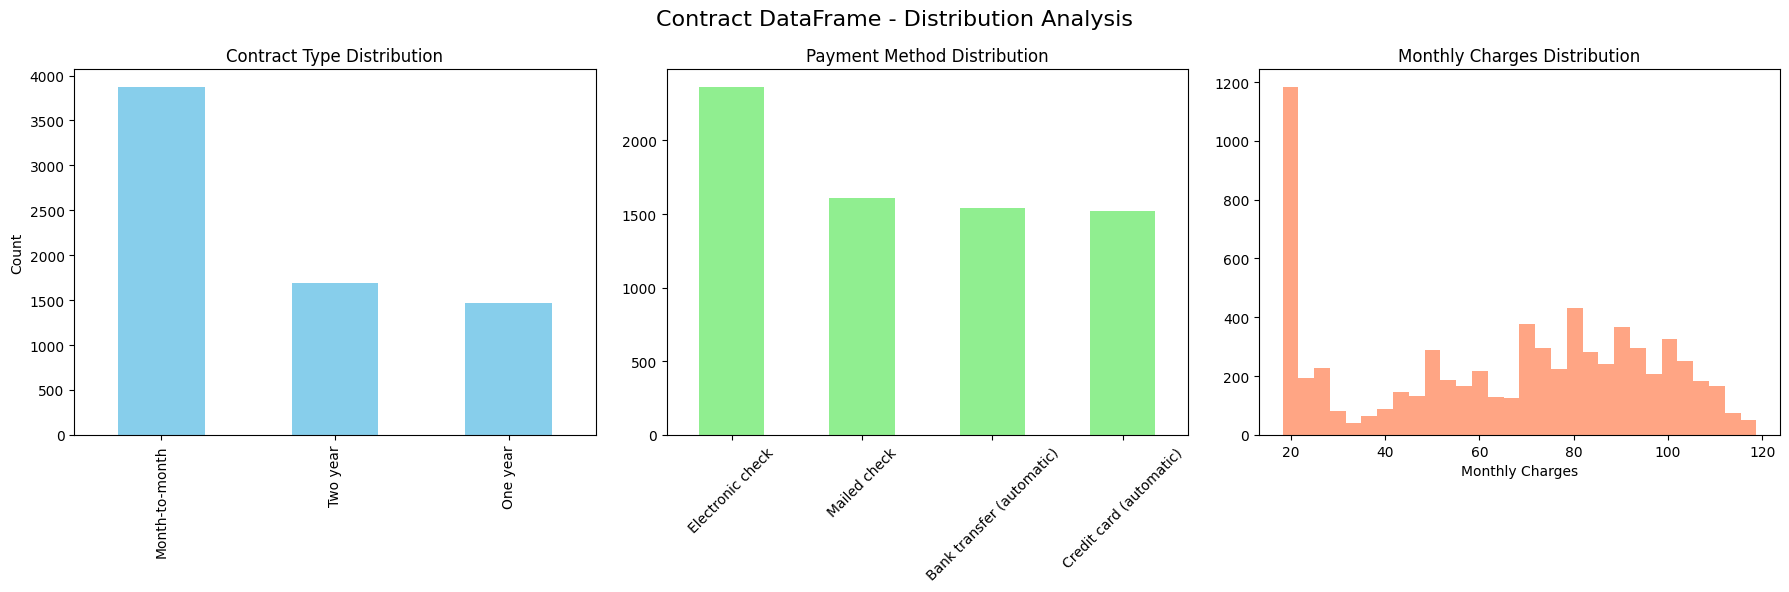

In [101]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Contract DataFrame - Distribution Analysis', fontsize=16)

# Contract Type distribution
contract_df['Type'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Contract Type Distribution')
axes[0].set_ylabel('Count')

# Payment Method distribution
contract_df['PaymentMethod'].value_counts().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Payment Method Distribution')
axes[1].tick_params(axis='x', rotation=45)

# Monthly Charges distribution
axes[2].hist(contract_df['MonthlyCharges'], bins=30, color='coral', alpha=0.7)
axes[2].set_title('Monthly Charges Distribution')
axes[2].set_xlabel('Monthly Charges')

plt.tight_layout()
plt.show()

In [102]:
print("===== personal_df =====")
print("Data shape:", personal_df.shape)
print("\nColumn names and types:")
display(personal_df.dtypes)
print("\nFirst few rows:")
display(personal_df.head())

===== personal_df =====
Data shape: (7043, 5)

Column names and types:


customerID       object
gender           object
SeniorCitizen     int64
Partner          object
Dependents       object
dtype: object


First few rows:


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [103]:
# Missing values
print("Missing values:")
print(personal_df.isnull().sum())

Missing values:
customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64


In [104]:
print(personal_df.duplicated().sum())

0


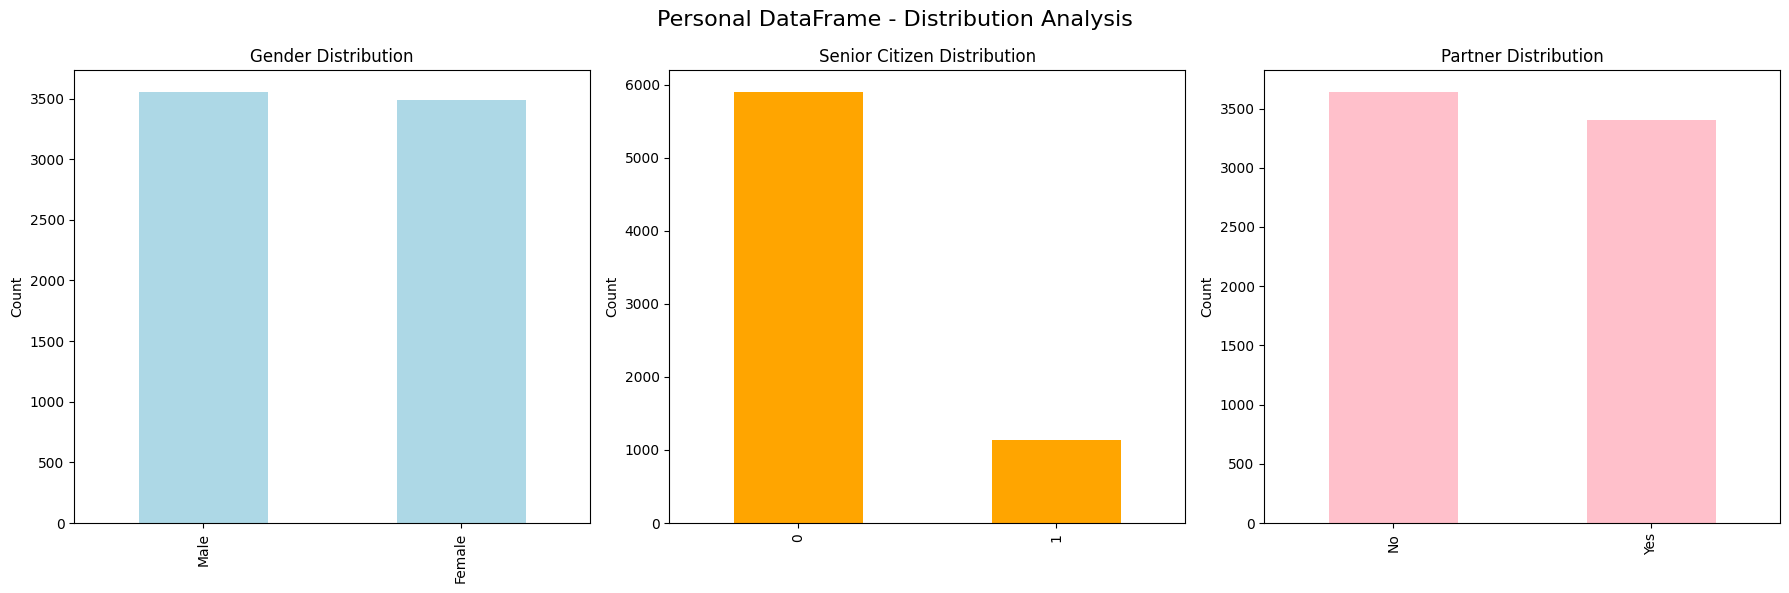

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Personal DataFrame - Distribution Analysis', fontsize=16)

# Gender distribution
personal_df['gender'].value_counts().plot(kind='bar', ax=axes[0], color='lightblue')
axes[0].set_title('Gender Distribution')
axes[0].set_ylabel('Count')

# Senior Citizen distribution
personal_df['SeniorCitizen'].value_counts().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Senior Citizen Distribution')
axes[1].set_ylabel('Count')

# Partner distribution
personal_df['Partner'].value_counts().plot(kind='bar', ax=axes[2], color='pink')
axes[2].set_title('Partner Distribution')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [106]:
print("===== internet_df =====")
print("Data shape:", internet_df.shape)
print("\nColumn names and types:")
display(internet_df.dtypes)

print("\nFirst few rows:")
display(internet_df.head())


===== internet_df =====
Data shape: (5517, 8)

Column names and types:


customerID          object
InternetService     object
OnlineSecurity      object
OnlineBackup        object
DeviceProtection    object
TechSupport         object
StreamingTV         object
StreamingMovies     object
dtype: object


First few rows:


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [107]:
# Missing values
print("Missing values:")
print(internet_df.isnull().sum())

Missing values:
customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64


In [108]:
print(internet_df.duplicated().sum())

0


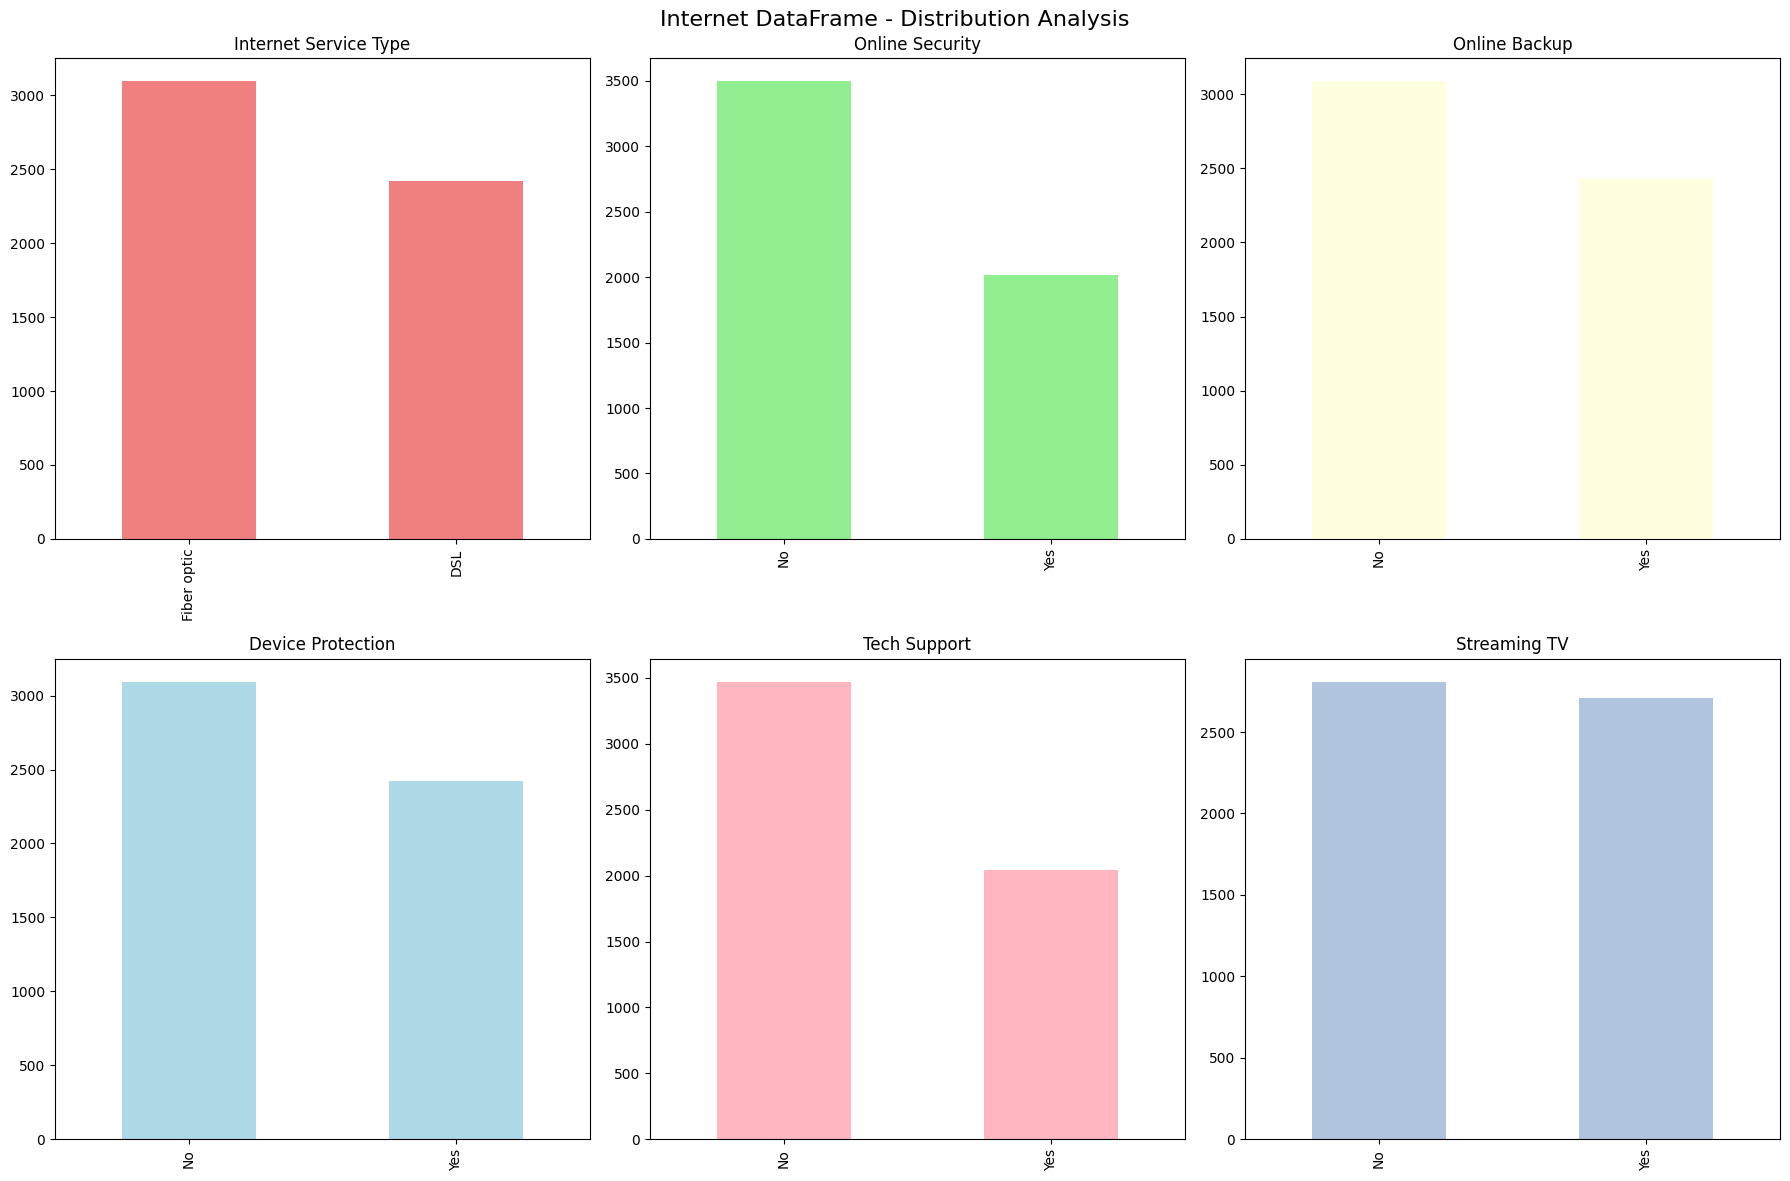

In [109]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Internet DataFrame - Distribution Analysis', fontsize=16)

# Row 1
internet_df['InternetService'].value_counts().plot(kind='bar', ax=axes[0,0], color='lightcoral')
axes[0,0].set_title('Internet Service Type')

internet_df['OnlineSecurity'].value_counts().plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Online Security')

internet_df['OnlineBackup'].value_counts().plot(kind='bar', ax=axes[0,2], color='lightyellow')
axes[0,2].set_title('Online Backup')

# Row 2
internet_df['DeviceProtection'].value_counts().plot(kind='bar', ax=axes[1,0], color='lightblue')
axes[1,0].set_title('Device Protection')

internet_df['TechSupport'].value_counts().plot(kind='bar', ax=axes[1,1], color='lightpink')
axes[1,1].set_title('Tech Support')

internet_df['StreamingTV'].value_counts().plot(kind='bar', ax=axes[1,2], color='lightsteelblue')
axes[1,2].set_title('Streaming TV')

plt.tight_layout()
plt.show()

In [110]:
print("===== phone_df =====")
print("Data shape:", phone_df.shape)

print("\nColumn names and types:")
display(phone_df.dtypes)

print("\nFirst few rows:")
display(phone_df.head())

===== phone_df =====
Data shape: (6361, 2)

Column names and types:


customerID       object
MultipleLines    object
dtype: object


First few rows:


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [111]:
# Missing values
print("Missing values:")
print(phone_df.isnull().sum())

Missing values:
customerID       0
MultipleLines    0
dtype: int64


In [112]:
print(phone_df.duplicated().sum())

0


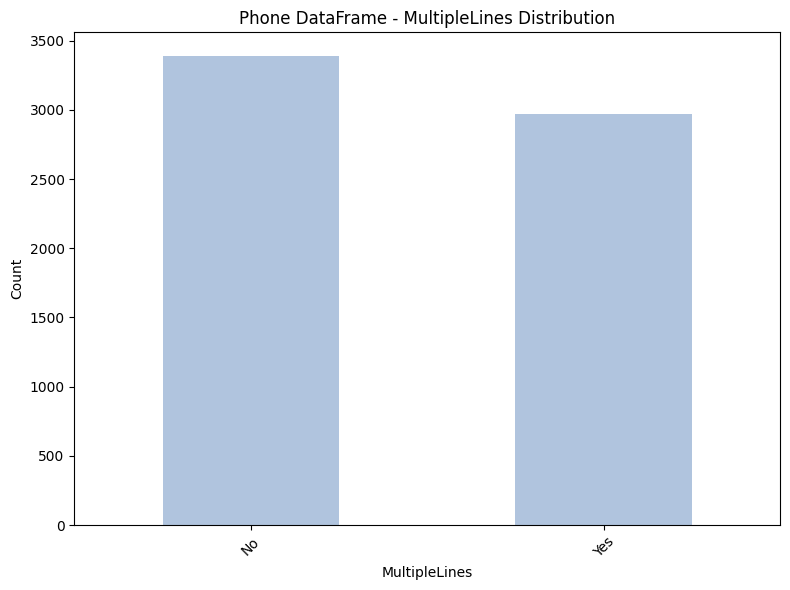

In [113]:
plt.figure(figsize=(8, 6))
phone_df['MultipleLines'].value_counts().plot(kind='bar', color='lightsteelblue')
plt.title('Phone DataFrame - MultipleLines Distribution')
plt.xlabel('MultipleLines')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [114]:
# Create churn variable (1 = churned, 0 = active)
contract_df['Churn'] = (contract_df['EndDate'] != 'No').astype(int)

# Verify the churn variable
print("Churn variable distribution:")
print(contract_df['Churn'].value_counts())
print(f"\nChurn rate: {contract_df['Churn'].mean():.1%}")

Churn variable distribution:
0    5174
1    1869
Name: Churn, dtype: int64

Churn rate: 26.5%


In [115]:
# Merge dataframes
contract_copy_df = contract_df.copy()

contract_personal_df = contract_copy_df.merge(personal_df,on='customerID', how='left')


In [116]:
# Verify merge
print(f"Shape of merged dataframe: {contract_personal_df.shape}")


Shape of merged dataframe: (7043, 13)


In [117]:
# Merge with internet_df

contract_personal_internet_df = contract_personal_df.merge(internet_df, on='customerID', how='left')

# Verify merge
print(f"Shape of merged dataframe: {contract_personal_internet_df.shape}")


Shape of merged dataframe: (7043, 20)


In [118]:
# Check for missing values after the merge
print("Missing values after internet merge:")
print(contract_personal_internet_df.isnull().sum())

Missing values after internet merge:
customerID             0
BeginDate              0
EndDate                0
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
dtype: int64


In [119]:
# Check if customers with missing internet data have phone service
customers_no_internet = contract_personal_internet_df[contract_personal_internet_df['InternetService'].isnull()]['customerID']
phone_customers_no_internet = phone_df[phone_df['customerID'].isin(customers_no_internet)]
print(f"Customers without internet service: {len(customers_no_internet)}")
print(f"Of these, how many have phone service: {len(phone_customers_no_internet)}")

Customers without internet service: 1526
Of these, how many have phone service: 1526


In [120]:
# Fill missing internet service values
internet_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_cols:
    if col == 'InternetService':
        contract_personal_internet_df[col] = contract_personal_internet_df[col].fillna('No Internet Service')
    else:
        contract_personal_internet_df[col] = contract_personal_internet_df[col].fillna('No Internet Service')

In [121]:
# Merge with phone_df
contract_personal_internet_phone_df = contract_personal_internet_df.merge(phone_df, on='customerID', how='left')

# Verify merge
print(f"Shape after phone merge: {contract_personal_internet_phone_df.shape}")

# Check for missing values
print("\nMissing values after phone merge:")
print(contract_personal_internet_phone_df.isnull().sum())

Shape after phone merge: (7043, 21)

Missing values after phone merge:
customerID            0
BeginDate             0
EndDate               0
Type                  0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          0
Churn                 0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
MultipleLines       682
dtype: int64


In [122]:
# Check what values exist in MultipleLines
print("MultipleLines values before filling:")
print(contract_personal_internet_phone_df['MultipleLines'].value_counts())

# Fill NaN values with "No" (meaning no multiple lines, just single line)
contract_personal_internet_phone_df['MultipleLines'] = contract_personal_internet_phone_df['MultipleLines'].fillna('No')

# Verify the result
print("\nMultipleLines values after filling:")
print(contract_personal_internet_phone_df['MultipleLines'].value_counts())

MultipleLines values before filling:
No     3390
Yes    2971
Name: MultipleLines, dtype: int64

MultipleLines values after filling:
No     4072
Yes    2971
Name: MultipleLines, dtype: int64


In [123]:
# Final check for missing values
print("Final missing values check:")
print(contract_personal_internet_phone_df.isnull().sum().sum())

# Quick overview of your complete dataset
print(f"\nFinal dataset shape: {contract_personal_internet_phone_df.shape}")
print(f"Total customers: {len(contract_personal_internet_phone_df)}")

Final missing values check:
0

Final dataset shape: (7043, 21)
Total customers: 7043


In [124]:
print("MultipleLines value counts:")
print(contract_personal_internet_phone_df['MultipleLines'].value_counts())
print("\n")

# Calculate churn rate by MultipleLines
churn_by_lines = contract_personal_internet_phone_df.groupby('MultipleLines')['Churn'].mean()
print("Churn rate by Multiple Lines:")
print(churn_by_lines.sort_values(ascending=False))

MultipleLines value counts:
No     4072
Yes    2971
Name: MultipleLines, dtype: int64


Churn rate by Multiple Lines:
MultipleLines
Yes    0.286099
No     0.250246
Name: Churn, dtype: float64


In [125]:
# Cross-tabulation to see the relationship more clearly
lines_churn_crosstab = pd.crosstab(contract_personal_internet_phone_df['MultipleLines'], contract_personal_internet_phone_df['Churn'], normalize='index')
print("\nChurn rate breakdown:")
print(lines_churn_crosstab)


Churn rate breakdown:
Churn                 0         1
MultipleLines                    
No             0.749754  0.250246
Yes            0.713901  0.286099


In [126]:
# Convert TotalCharges to numeric
contract_personal_internet_phone_df['TotalCharges'] = pd.to_numeric(
    contract_personal_internet_phone_df['TotalCharges'], errors='coerce'
)

# Check data types
print(contract_personal_internet_phone_df.dtypes)


customerID           object
BeginDate            object
EndDate              object
Type                 object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
MultipleLines        object
dtype: object


In [127]:
# Calculate tenure in months
contract_personal_internet_phone_df['tenure_months'] = (
    pd.to_datetime('2020-02-01') - pd.to_datetime(contract_personal_internet_phone_df['BeginDate'])
).dt.days / 30.44



In [128]:
# Define the service columns
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

In [129]:
# Count how many "Yes" values each customer has across service columns & create new column
contract_personal_internet_phone_df['addon_count'] = (
    contract_personal_internet_phone_df[service_cols] == 'Yes'
).sum(axis=1)

In [130]:
# Filter to see just 1 add on
filtered_addon_1 = contract_personal_internet_phone_df[contract_personal_internet_phone_df['addon_count'] == 1]

In [131]:
# Count "Yes" values for each service among customers with 1 add-on
service_counts = (filtered_addon_1[service_cols] == 'Yes').sum()
print("Service counts for customers with exactly 1 add-on:")
print(service_counts.sort_values(ascending=False))

Service counts for customers with exactly 1 add-on:
MultipleLines       552
OnlineBackup        124
OnlineSecurity      118
StreamingTV         105
StreamingMovies     101
DeviceProtection     80
TechSupport          78
dtype: int64


In [132]:
print(contract_personal_internet_phone_df['OnlineSecurity'].unique())

['No' 'Yes' 'No Internet Service']


In [133]:
# Verify column created correctly
print("Columns in the dataframe:")
print(contract_personal_internet_phone_df.columns.tolist())

# Check the addon_count distribution
print("\nAddon count distribution:")
print(contract_personal_internet_phone_df['addon_count'].value_counts().sort_index())

Columns in the dataframe:
['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines', 'tenure_months', 'addon_count']

Addon count distribution:
0    1667
1    1158
2     957
3     978
4     933
5     722
6     420
7     208
Name: addon_count, dtype: int64


In [134]:
# Calculate churn rate by addon count
churn_by_addons = contract_personal_internet_phone_df.groupby('addon_count')['Churn'].mean()
print("Churn rate by number of add-on services:")
print(churn_by_addons.sort_index())

Churn rate by number of add-on services:
addon_count
0    0.207558
1    0.344560
2    0.377220
3    0.312883
4    0.257235
5    0.217452
6    0.116667
7    0.052885
Name: Churn, dtype: float64


In [135]:
# Analyze churn by payment method
churn_by_payment = contract_personal_internet_phone_df.groupby('PaymentMethod')['Churn'].mean()
print("Churn rate by payment method:")
print(churn_by_payment.sort_values(ascending=False))

Churn rate by payment method:
PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn, dtype: float64


In [136]:
# Drop columns
contract_personal_internet_phone_df = contract_personal_internet_phone_df.drop(columns=['customerID', 'BeginDate', 'EndDate', 'TotalCharges', 'Churn'])

In [137]:
# Check data types and identify categorical columns
print("Current data types:")
print(contract_personal_internet_phone_df.dtypes)
print("\n" + "="*50)

# Identify categorical columns (object type)
categorical_cols = contract_personal_internet_phone_df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")
print(f"Number of categorical columns: {len(categorical_cols)}")

Current data types:
Type                 object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
MultipleLines        object
tenure_months       float64
addon_count           int64
dtype: object

Categorical columns to encode: ['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
Number of categorical columns: 14


In [138]:
# Get all categorical columns
categorical_cols = contract_personal_internet_phone_df.select_dtypes(include=['object']).columns

# Display unique values for each categorical column
for col in categorical_cols:
    print(f"{col}: {contract_personal_internet_phone_df[col].unique()}")
    print(f"Number of unique values: {contract_personal_internet_phone_df[col].nunique()}")
    print("-" * 50)

Type: ['Month-to-month' 'One year' 'Two year']
Number of unique values: 3
--------------------------------------------------
PaperlessBilling: ['Yes' 'No']
Number of unique values: 2
--------------------------------------------------
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Number of unique values: 4
--------------------------------------------------
gender: ['Female' 'Male']
Number of unique values: 2
--------------------------------------------------
Partner: ['Yes' 'No']
Number of unique values: 2
--------------------------------------------------
Dependents: ['No' 'Yes']
Number of unique values: 2
--------------------------------------------------
InternetService: ['DSL' 'Fiber optic' 'No Internet Service']
Number of unique values: 3
--------------------------------------------------
OnlineSecurity: ['No' 'Yes' 'No Internet Service']
Number of unique values: 3
--------------------------------------------------
OnlineB

In [139]:
# Separate binary and multi-class columns
binary_cols = []
multi_class_cols = []

for col in categorical_cols:
    unique_count = contract_personal_internet_phone_df[col].nunique()
    if unique_count == 2:
        binary_cols.append(col)
    else:
        multi_class_cols.append(col)

print("Binary columns (2 values):")
print(binary_cols)
print(f"\nMulti-class columns (3+ values):")
print(multi_class_cols)

Binary columns (2 values):
['PaperlessBilling', 'gender', 'Partner', 'Dependents', 'MultipleLines']

Multi-class columns (3+ values):
['Type', 'PaymentMethod', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


In [140]:
def encode_categorical_features(df):
    """
    Encode categorical features using mixed approach:
    - Binary encoding for 2-value columns
    - One-hot encoding for multi-class columns
    - Replace "No Internet Service" with "No" for service columns
    """
    df_encoded = df.copy()
    
    # Replace "No Internet Service" with "No" for service columns
    service_cols_with_no_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                                     'TechSupport', 'StreamingTV', 'StreamingMovies']
    
    for col in service_cols_with_no_internet:
        df_encoded[col] = df_encoded[col].replace('No Internet Service', 'No')
    
    # Define column groups after replacement
    binary_cols = ['PaperlessBilling', 'gender', 'Partner', 'Dependents', 'MultipleLines'] + service_cols_with_no_internet
    multi_class_cols = ['Type', 'PaymentMethod', 'InternetService']
    
    # Binary encoding (No=0, Yes=1, Male=0, Female=1)
    for col in binary_cols:
        if col == 'gender':
            df_encoded[col] = (df_encoded[col] == 'Female').astype(int)
        else:
            df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)
    
    # One-hot encoding for multi-class columns
    df_encoded = pd.get_dummies(df_encoded, columns=multi_class_cols, drop_first=True)
    
    return df_encoded

# Apply the encoding function
encoded_df = encode_categorical_features(contract_personal_internet_phone_df)

In [141]:
# Check the shape before encoding
print("Before encoding:")
print(f"Shape: {contract_personal_internet_phone_df.shape}")
print(f"Columns: {len(contract_personal_internet_phone_df.columns)}")

# Apply your encoding function
encoded_df = encode_categorical_features(contract_personal_internet_phone_df)

# Check the results
print("\nAfter encoding:")
print(f"Shape: {encoded_df.shape}")
print(f"Columns: {len(encoded_df.columns)}")

Before encoding:
Shape: (7043, 18)
Columns: 18

After encoding:
Shape: (7043, 22)
Columns: 22


In [142]:
# Display the column names and data types of encoded dataset
print("=== ENCODED DATASET OVERVIEW ===")
print(f"Shape: {encoded_df.shape}")
print(f"Total columns: {len(encoded_df.columns)}")
print("\nColumn names and data types:")
print(encoded_df.dtypes)

=== ENCODED DATASET OVERVIEW ===
Shape: (7043, 22)
Total columns: 22

Column names and data types:
PaperlessBilling                           int64
MonthlyCharges                           float64
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
MultipleLines                              int64
tenure_months                            float64
addon_count                                int64
Type_One year                              uint8
Type_Two year                              uint8
PaymentMethod_Credit card (automatic)      uint8
PaymentMethod_Elect

In [143]:
# Check the first few rows to see the encoded values
print("\n=== FIRST 5 ROWS OF ENCODED DATA ===")
print(encoded_df.head())


=== FIRST 5 ROWS OF ENCODED DATA ===
   PaperlessBilling  MonthlyCharges  gender  SeniorCitizen  Partner  \
0                 1           29.85       1              0        1   
1                 0           56.95       0              0        0   
2                 1           53.85       0              0        0   
3                 0           42.30       0              0        0   
4                 1           70.70       1              0        0   

   Dependents  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0           0               0             1                 0            0   
1           0               1             0                 1            0   
2           0               1             1                 0            0   
3           0               1             0                 1            1   
4           0               0             0                 0            0   

   ...  MultipleLines  tenure_months  addon_count  Type_One year  

In [144]:
# Examine the new one-hot encoded columns specifically
print("\n=== NEW ONE-HOT ENCODED COLUMNS ===")
new_columns = [col for col in encoded_df.columns if '_' in col]
print("New columns created from one-hot encoding:")
for col in new_columns:
    print(f"- {col}: {encoded_df[col].unique()}")


=== NEW ONE-HOT ENCODED COLUMNS ===
New columns created from one-hot encoding:
- tenure_months: [ 1.01839685 34.03416557  4.04073587 45.03942181  5.02628121 11.07095926
 22.04336399 10.05256242 31.04467806 62.02365309 13.00919842 16.03153745
 58.04862024 53.02233903 25.         69.05387648 52.03679369 71.05781866
 21.05781866  3.02233903 11.99080158 49.01445466 30.02628121 50.03285151
 71.97766097 20.03942181  2.03679369 27.00394218  8.04862024 46.02496715
 35.97240473 14.02759527 70.03942181 17.01708279 63.00919842 43.03547963
 59.9868594  19.05387648 66.03153745 47.04336399 18.03547963 64.02759527
 56.04467806 42.01708279  9.06701708 35.05256242 47.99605782 29.00788436
 65.0131406  26.01839685 38.00919842 32.03022339 57.0630749  40.0131406
 40.99868594  6.04467806  7.0630749  33.04862024 28.02233903 67.0499343
 23.06176084 61.00525624 15.0131406  59.06701708 23.98160315 44.02102497
 54.04073587 51.01839685 68.03547963 36.99080158 55.05913272  0.
 38.99474376 75.         72.99605782 

In [145]:
# Verify binary encoding worked correctly
print("\n=== BINARY ENCODED COLUMNS ===")
binary_encoded_cols = ['PaperlessBilling', 'gender', 'Partner', 'Dependents', 
                      'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
                      'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_encoded_cols:
    if col in encoded_df.columns:
        print(f"{col}: {encoded_df[col].unique()} (should be [0, 1])")


=== BINARY ENCODED COLUMNS ===
PaperlessBilling: [1 0] (should be [0, 1])
gender: [1 0] (should be [0, 1])
Partner: [1 0] (should be [0, 1])
Dependents: [0 1] (should be [0, 1])
MultipleLines: [0 1] (should be [0, 1])
OnlineSecurity: [0 1] (should be [0, 1])
OnlineBackup: [1 0] (should be [0, 1])
DeviceProtection: [0 1] (should be [0, 1])
TechSupport: [0 1] (should be [0, 1])
StreamingTV: [0 1] (should be [0, 1])
StreamingMovies: [0 1] (should be [0, 1])


In [146]:
# Recreate target variable from the original contract data
# Remember: Churn = 1 if EndDate != 'No', otherwise 0
target = (contract_df['EndDate'] != 'No').astype(int)

print("Target variable (Churn) distribution:")
print(target.value_counts())
print(f"\nChurn rate: {target.mean():.1%}")

# Verify it matches the original dataset order
print(f"\nTarget variable shape: {target.shape}")
print(f"Encoded features shape: {encoded_df.shape}")

Target variable (Churn) distribution:
0    5174
1    1869
Name: EndDate, dtype: int64

Churn rate: 26.5%

Target variable shape: (7043,)
Encoded features shape: (7043, 22)


In [147]:
# Create final modeling dataset
# Features (X) and target (y)

X = encoded_df.copy()
y = target.copy()

print("=== FINAL MODELING DATASET ===")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")


=== FINAL MODELING DATASET ===
Features (X) shape: (7043, 22)
Target (y) shape: (7043,)
Target distribution:
0    5174
1    1869
Name: EndDate, dtype: int64


In [148]:
# Create interaction features that might capture churn patterns
X_enhanced = X.copy()

# Contract + Payment interaction (high-risk combination)
X_enhanced['electronic_check_monthly'] = (
    X_enhanced['PaymentMethod_Electronic check'] * 
    (X_enhanced['Type_One year'] == 0) * (X_enhanced['Type_Two year'] == 0)  # Month-to-month
)

# Service bundle completeness
X_enhanced['service_completeness'] = (
    X_enhanced['OnlineSecurity'] + X_enhanced['OnlineBackup'] + 
    X_enhanced['DeviceProtection'] + X_enhanced['TechSupport']
) / 4

# High-value customer indicator
X_enhanced['high_value_customer'] = (
    (X_enhanced['MonthlyCharges'] > X_enhanced['MonthlyCharges'].quantile(0.75)) & 
    (X_enhanced['tenure_months'] > 24)
).astype(int)

print("Enhanced features created!")
print(f"New feature count: {X_enhanced.shape[1]} (was {X.shape[1]})")

Enhanced features created!
New feature count: 25 (was 22)


In [149]:
# Create more targeted features based on importance analysis
X_targeted = X.copy()

# Handle any missing values first
X_targeted['tenure_months'] = X_targeted['tenure_months'].fillna(0)

# 1. Tenure-based risk categories
X_targeted['tenure_risk'] = pd.cut(
    X_targeted['tenure_months'], 
    bins=[0, 12, 24, 48, float('inf')], 
    labels=[3, 2, 1, 0],  # Higher number = higher risk
    include_lowest=True  # Include the lowest value
)
# Convert to int after handling NaN
X_targeted['tenure_risk'] = X_targeted['tenure_risk'].astype(int)

# 2. High-risk service combination (fiber + electronic check)
X_targeted['fiber_electronic_risk'] = (
    X_targeted['InternetService_Fiber optic'] * 
    X_targeted['PaymentMethod_Electronic check']
)

# 3. Contract protection score
X_targeted['contract_protection'] = (
    X_targeted['Type_Two year'] * 2 + 
    X_targeted['Type_One year'] * 1
)

# 4. Tenure-payment interaction (combines top 2 predictors)
X_targeted['tenure_payment_risk'] = (
    X_targeted['PaymentMethod_Electronic check'] * 
    (X_targeted['tenure_months'] < 12).astype(int)
)

print("=== TARGETED FEATURE ENGINEERING ===")
print(f"Original features: {X.shape[1]}")
print(f"Enhanced features: {X_targeted.shape[1]}")
print(f"New features added: {X_targeted.shape[1] - X.shape[1]}")

=== TARGETED FEATURE ENGINEERING ===
Original features: 22
Enhanced features: 26
New features added: 4


In [150]:
# Verification that everything aligns
print("=== VERIFICATION ===")
print(f"All customers accounted for: {len(X) == len(y) == len(contract_df)}")
print(f"No missing values in features: {X.isnull().sum().sum() == 0}")
print(f"Target is binary: {set(y.unique()) == {0, 1}}")

=== VERIFICATION ===
All customers accounted for: True
No missing values in features: True
Target is binary: True


In [151]:

# Create proper train/validation/test split
# First split: separate test set 


X_temp, X_test, y_temp, y_test, X_enhanced_temp, X_enhanced_test , X_targeted_temp, X_targeted_test = train_test_split(

    X, y, X_enhanced, X_targeted, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)


# Second split: create train and validation sets


X_train, X_val, y_train, y_val, X_train_enhanced, X_val_enhanced, X_train_targeted, X_val_targeted = train_test_split(
    X_temp, y_temp, X_enhanced_temp, X_targeted_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)





print("=== PROPER DATA SPLIT RESULTS ===")
print(f"Training set: {X_train.shape[0]} customers (60%)")
print(f"Validation set: {X_val.shape[0]} customers (20%)")  
print(f"Test set: {X_test.shape[0]} customers (20%)")

# Verify stratification
print(f"\nChurn rate verification:")
print(f"Original dataset churn rate: {y.mean():.1%}")
print(f"Training set churn rate: {y_train.mean():.1%}")
print(f"Validation set churn rate: {y_val.mean():.1%}")
print(f"Test set churn rate: {y_test.mean():.1%}")

=== PROPER DATA SPLIT RESULTS ===
Training set: 4225 customers (60%)
Validation set: 1409 customers (20%)
Test set: 1409 customers (20%)

Churn rate verification:
Original dataset churn rate: 26.5%
Training set churn rate: 26.5%
Validation set churn rate: 26.5%
Test set churn rate: 26.5%


In [152]:
# Verify the stratification worked correctly
print("\n=== CHURN RATE VERIFICATION ===")
print(f"Original dataset churn rate: {y.mean():.1%}")
print(f"Training set churn rate: {y_train.mean():.1%}")
print(f"Test set churn rate: {y_val.mean():.1%}")

print(f"\nTraining set distribution:")
print(y_train.value_counts())
print(f"\nTest set distribution:")
print(y_val.value_counts())


=== CHURN RATE VERIFICATION ===
Original dataset churn rate: 26.5%
Training set churn rate: 26.5%
Test set churn rate: 26.5%

Training set distribution:
0    3104
1    1121
Name: EndDate, dtype: int64

Test set distribution:
0    1035
1     374
Name: EndDate, dtype: int64


In [153]:
# Display the final shapes for modeling
print("\n=== FINAL DATASET SHAPES ===")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_val: {y_val.shape}")


=== FINAL DATASET SHAPES ===
X_train: (4225, 22)
X_val: (1409, 22)
y_train: (4225,)
y_val: (1409,)


In [154]:
# Create and train a Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

print("=== LOGISTIC REGRESSION MODEL TRAINED ===")
print("Model training completed successfully!")

=== LOGISTIC REGRESSION MODEL TRAINED ===
Model training completed successfully!


In [155]:
# Make predictions
y_train_pred = log_reg.predict(X_train)
y_val_pred = log_reg.predict(X_val)

# Get prediction probabilities for AUC calculation
y_train_proba = log_reg.predict_proba(X_train)[:, 1]  # Probability of churn (class 1)
y_val_proba = log_reg.predict_proba(X_val)[:, 1]

print("=== PREDICTIONS GENERATED ===")
print("Training and test predictions ready for evaluation!")

=== PREDICTIONS GENERATED ===
Training and test predictions ready for evaluation!


In [156]:
# Calculate AUC-ROC scores
train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_val, y_val_proba)

print("=== MODEL PERFORMANCE ===")
print(f"Training AUC-ROC: {train_auc:.4f}")
print(f"Test AUC-ROC: {test_auc:.4f}")

# Check against project requirements
if test_auc >= 0.88:
    print("🎉 Excellent! 6 SP - AUC-ROC ≥ 0.88")
elif test_auc >= 0.87:
    print("🎯 Great! 5.5 SP - AUC-ROC ≥ 0.87")
elif test_auc >= 0.85:
    print("✅ Good! 5 SP - AUC-ROC ≥ 0.85")
elif test_auc >= 0.81:
    print("👍 Solid! 4.5 SP - AUC-ROC ≥ 0.81")
elif test_auc >= 0.75:
    print("📈 Decent! 4 SP - AUC-ROC ≥ 0.75")
else:
    print("📊 Baseline established - room for improvement!")

=== MODEL PERFORMANCE ===
Training AUC-ROC: 0.8442
Test AUC-ROC: 0.8266
👍 Solid! 4.5 SP - AUC-ROC ≥ 0.81


In [157]:
# Let's get more detailed performance metrics first
print("=== DETAILED PERFORMANCE ANALYSIS ===")
print("\nClassification Report (Test Set):")
print(classification_report(y_val, y_val_pred))

print(f"\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_val, y_val_pred))

=== DETAILED PERFORMANCE ANALYSIS ===

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix (Test Set):
[[929 106]
 [177 197]]


Precision for Non-Churn (0): 84% - When model predicts "won't churn", it's right 84% of the time
Recall for Non-Churn (0): 89% - Model catches 89% of actual non-churners
Precision for Churn (1): 62% - When model predicts "will churn", it's right 62% of the time
Recall for Churn (1): 52% - Model catches only 52% of actual churners

True Negatives: 918 (correctly identified non-churners)
False Positives: 117 (incorrectly predicted churn)
False Negatives: 181 (missed churners)
True Positives: 193 (correctly identified churners)

In [158]:
# Check feature importance to understand what's driving predictions
feature_importance = abs(log_reg.coef_[0])
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("=== TOP 10 MOST IMPORTANT FEATURES ===")
print(importance_df.head(10))

=== TOP 10 MOST IMPORTANT FEATURES ===
                                feature  importance
16                        Type_Two year    1.790626
20          InternetService_Fiber optic    1.448091
21  InternetService_No Internet Service    1.424570
15                        Type_One year    0.940197
10                          StreamingTV    0.438610
6                        OnlineSecurity    0.420208
18       PaymentMethod_Electronic check    0.414664
11                      StreamingMovies    0.356850
9                           TechSupport    0.338333
0                      PaperlessBilling    0.312896


Type_Two year (1.63) - Two-year contracts strongly prevent churn
InternetService_No Internet Service (1.37) - No internet service affects churn
InternetService_Fiber optic (1.32) - Fiber optic service impacts churn
Type_One year (0.89) - One-year contracts also reduce churn
PaymentMethod_Electronic check (0.44) - Electronic check increases churn risk

In [159]:
# Create individual models
print("=== CREATING ENSEMBLE MODELS ===")

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    max_depth=10
)

# Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100, 
    random_state=42, 
    max_depth=6
)

# SVM with probability estimates
svm_model = SVC(
    probability=True,  # soft voting
    random_state=42,
    kernel='rbf'
)

print("Individual models created successfully!")

=== CREATING ENSEMBLE MODELS ===
Individual models created successfully!


In [160]:
# Create the Voting Ensemble
voting_ensemble = VotingClassifier(
    estimators=[
        ('logistic', log_reg),      # Existing model
        ('random_forest', rf_model),
        ('gradient_boost', gb_model),
        ('svm', svm_model)
    ],
    voting='soft'  # Soft voting 
)

print("=== TRAINING ENSEMBLE MODEL ===")
voting_ensemble.fit(X_train, y_train)
print("Ensemble training completed!")

=== TRAINING ENSEMBLE MODEL ===
Ensemble training completed!


In [161]:
# Make ensemble predictions
print("=== ENSEMBLE MODEL EVALUATION ===")

# Get ensemble predictions and probabilities
y_train_ensemble_pred = voting_ensemble.predict(X_train)
y_valt_ensemble_pred = voting_ensemble.predict(X_val)

# Get prediction probabilities for AUC calculation
y_train_ensemble_proba = voting_ensemble.predict_proba(X_train)[:, 1]
y_val_ensemble_proba = voting_ensemble.predict_proba(X_val)[:, 1]

print("Ensemble predictions generated!")

=== ENSEMBLE MODEL EVALUATION ===
Ensemble predictions generated!


In [162]:
# Calculate ensemble AUC-ROC scores
train_ensemble_auc = roc_auc_score(y_train, y_train_ensemble_proba)
test_ensemble_auc = roc_auc_score(y_val, y_val_ensemble_proba)

print("=== ENSEMBLE vs BASELINE COMPARISON ===")
print(f"BASELINE Logistic Regression:")
print(f"  Training AUC: {train_auc:.4f}")
print(f"  Test AUC: {test_auc:.4f}")
print(f"\nENSEMBLE (4 models):")
print(f"  Training AUC: {train_ensemble_auc:.4f}")
print(f"  Test AUC: {test_ensemble_auc:.4f}")
print(f"\nIMPROVEMENT:")
print(f"  Training: +{train_ensemble_auc - train_auc:.4f}")
print(f"  Test: +{test_ensemble_auc - test_auc:.4f}")

=== ENSEMBLE vs BASELINE COMPARISON ===
BASELINE Logistic Regression:
  Training AUC: 0.8442
  Test AUC: 0.8266

ENSEMBLE (4 models):
  Training AUC: 0.9327
  Test AUC: 0.8428

IMPROVEMENT:
  Training: +0.0884
  Test: +0.0162


In [163]:
# Train individual models and evaluate performance
print("=== INDIVIDUAL MODEL TRAINING & EVALUATION ===")

# Dictionary to store results
individual_results = {}

# 1. Random Forest (already defined)
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# RF predictions
rf_train_proba = rf_model.predict_proba(X_train)[:, 1]
rf_test_proba = rf_model.predict_proba(X_val)[:, 1]
rf_train_auc = roc_auc_score(y_train, rf_train_proba)
rf_test_auc = roc_auc_score(y_val, rf_test_proba)

individual_results['Random Forest'] = {
    'train_auc': rf_train_auc,
    'test_auc': rf_test_auc,
    'gap': rf_train_auc - rf_test_auc
}

print(f"Random Forest - Train AUC: {rf_train_auc:.4f}, Test AUC: {rf_test_auc:.4f}")

=== INDIVIDUAL MODEL TRAINING & EVALUATION ===
Training Random Forest...
Random Forest - Train AUC: 0.9572, Test AUC: 0.8396


In [164]:
# Test with reduced complexity

rf_simple = RandomForestClassifier(
    n_estimators=100,    
    max_depth=5,           # Reduce from 10 to 5
    random_state=42
)


rf_simple.fit(X_train, y_train)

# Evaluate
rf_simple_train_proba = rf_simple.predict_proba(X_train)[:, 1]
rf_simple_test_proba = rf_simple.predict_proba(X_val)[:, 1]

print(f"Simplified RF - Train AUC: {roc_auc_score(y_train, rf_simple_train_proba):.4f}")
print(f"Simplified RF - Test AUC: {roc_auc_score(y_val, rf_simple_test_proba):.4f}")

Simplified RF - Train AUC: 0.8574
Simplified RF - Test AUC: 0.8351


In [165]:
# More Random Forest configurations
rf_configs = [
    {'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 10},
    {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 5}, 
    {'n_estimators': 100, 'max_depth': 7, 'min_samples_split': 10},
    {'n_estimators': 200, 'max_depth': 4, 'min_samples_split': 15}
]

print("=== RANDOM FOREST HYPERPARAMETER TUNING ===")
best_config = None
best_test_auc = 0
best_gap = float('inf')

for i, config in enumerate(rf_configs):
    rf_test = RandomForestClassifier(random_state=42, **config)
    rf_test.fit(X_train, y_train)
    
    train_proba = rf_test.predict_proba(X_train)[:, 1]
    test_proba = rf_test.predict_proba(X_val)[:, 1]
    
    train_auc = roc_auc_score(y_train, train_proba)
    test_auc = roc_auc_score(y_val, test_proba)
    gap = train_auc - test_auc
    
    print(f"Config {i+1}: {config}")
    print(f"  Train AUC: {train_auc:.4f}, Test AUC: {test_auc:.4f}, Gap: {gap:.4f}")
    
    if test_auc > best_test_auc and gap < 0.05:  # Good test performance + low overfitting
        best_test_auc = test_auc
        best_config = config
        best_gap = gap
    print()

=== RANDOM FOREST HYPERPARAMETER TUNING ===
Config 1: {'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 10}
  Train AUC: 0.8409, Test AUC: 0.8271, Gap: 0.0138

Config 2: {'n_estimators': 150, 'max_depth': 5, 'min_samples_split': 5}
  Train AUC: 0.8585, Test AUC: 0.8358, Gap: 0.0227

Config 3: {'n_estimators': 100, 'max_depth': 7, 'min_samples_split': 10}
  Train AUC: 0.8855, Test AUC: 0.8388, Gap: 0.0467

Config 4: {'n_estimators': 200, 'max_depth': 4, 'min_samples_split': 15}
  Train AUC: 0.8507, Test AUC: 0.8335, Gap: 0.0172



In [166]:

# 2. Gradient Boosting
print("Training Gradient Boosting...")
gb_model.fit(X_train, y_train)

gb_train_proba = gb_model.predict_proba(X_train)[:, 1]
gb_test_proba = gb_model.predict_proba(X_val)[:, 1]
gb_train_auc = roc_auc_score(y_train, gb_train_proba)
gb_test_auc = roc_auc_score(y_val, gb_test_proba)

individual_results['Gradient Boosting'] = {
    'train_auc': gb_train_auc,
    'test_auc': gb_test_auc,
    'gap': gb_train_auc - gb_test_auc
}

print(f"Gradient Boosting - Train AUC: {gb_train_auc:.4f}, Test AUC: {gb_test_auc:.4f}")


Training Gradient Boosting...
Gradient Boosting - Train AUC: 0.9725, Test AUC: 0.8389


In [167]:
# Test with reduced complexity
gb_simple = GradientBoostingClassifier(  
    n_estimators=100,    
    max_depth=5,           # Reduce from default
    random_state=42
)

gb_simple.fit(X_train, y_train)  

# Evaluate
gb_simple_train_proba = gb_simple.predict_proba(X_train)[:, 1]
gb_simple_test_proba = gb_simple.predict_proba(X_val)[:, 1]

print(f"Simplified GB - Train AUC: {roc_auc_score(y_train, gb_simple_train_proba):.4f}")
print(f"Simplified GB - Test AUC: {roc_auc_score(y_val, gb_simple_test_proba):.4f}")  

Simplified GB - Train AUC: 0.9424
Simplified GB - Test AUC: 0.8423


In [168]:
gb_depth2 = GradientBoostingClassifier(
    n_estimators=100,    
    max_depth=2,           # Very conservative
    random_state=42
)

gb_depth2.fit(X_train, y_train)

gb_depth2_train_proba = gb_depth2.predict_proba(X_train)[:, 1]
gb_depth2_test_proba = gb_depth2.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train, gb_depth2_train_proba)
test_auc = roc_auc_score(y_val, gb_depth2_test_proba)

print(f"GB max_depth=2 - Train AUC: {train_auc:.4f}")
print(f"GB max_depth=2 - Test AUC: {test_auc:.4f}")
print(f"Gap: {train_auc - test_auc:.4f}")

GB max_depth=2 - Train AUC: 0.8739
GB max_depth=2 - Test AUC: 0.8551
Gap: 0.0187


In [169]:
# Test different n_estimators values
estimator_values = [50, 100, 150, 200]

for n_est in estimator_values:
    gb_test = GradientBoostingClassifier(
        n_estimators=n_est,
        max_depth=2,           # Keep max_depth
        random_state=42
    )
    
    gb_test.fit(X_train, y_train)
    
    train_proba = gb_test.predict_proba(X_train)[:, 1]
    test_proba = gb_test.predict_proba(X_val)[:, 1]
    
    train_auc = roc_auc_score(y_train, train_proba)
    test_auc = roc_auc_score(y_val, test_proba)
    gap = train_auc - test_auc
    
    print(f"n_estimators={n_est} - Train: {train_auc:.4f}, Test: {test_auc:.4f}, Gap: {gap:.4f}")

n_estimators=50 - Train: 0.8648, Test: 0.8523, Gap: 0.0125
n_estimators=100 - Train: 0.8739, Test: 0.8551, Gap: 0.0187
n_estimators=150 - Train: 0.8788, Test: 0.8547, Gap: 0.0241
n_estimators=200 - Train: 0.8828, Test: 0.8539, Gap: 0.0288


In [170]:
# 3. SVM
print("Training SVM...")
svm_model.fit(X_train, y_train)

svm_train_proba = svm_model.predict_proba(X_train)[:, 1]
svm_test_proba = svm_model.predict_proba(X_val)[:, 1]
svm_train_auc = roc_auc_score(y_train, svm_train_proba)
svm_test_auc = roc_auc_score(y_val, svm_test_proba)

individual_results['SVM'] = {
    'train_auc': svm_train_auc,
    'test_auc': svm_test_auc,
    'gap': svm_train_auc - svm_test_auc
}

print(f"SVM - Train AUC: {svm_train_auc:.4f}, Test AUC: {svm_test_auc:.4f}")

Training SVM...
SVM - Train AUC: 0.7686, Test AUC: 0.7818


In [171]:
# Create ensemble with best-tuned models
best_rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=7, 
    min_samples_split=10,
    random_state=42
)

best_gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=2,
    random_state=42
)

# Create the optimized ensemble
optimized_ensemble = VotingClassifier(
    estimators=[
        ('logistic', log_reg),
        ('best_rf', best_rf),
        ('best_gb', best_gb)
    ],
    voting='soft'
)

print("=== TRAINING OPTIMIZED ENSEMBLE ===")
optimized_ensemble.fit(X_train, y_train)

# Evaluate the optimized ensemble
ensemble_train_proba = optimized_ensemble.predict_proba(X_train)[:, 1]
ensemble_test_proba = optimized_ensemble.predict_proba(X_val)[:, 1]

ensemble_train_auc = roc_auc_score(y_train, ensemble_train_proba)
ensemble_test_auc = roc_auc_score(y_val, ensemble_test_proba)

print(f"Optimized Ensemble - Train AUC: {ensemble_train_auc:.4f}")
print(f"Optimized Ensemble - Test AUC: {ensemble_test_auc:.4f}")
print(f"Gap: {ensemble_train_auc - ensemble_test_auc:.4f}")

=== TRAINING OPTIMIZED ENSEMBLE ===
Optimized Ensemble - Train AUC: 0.8733
Optimized Ensemble - Test AUC: 0.8455
Gap: 0.0278


In [172]:

# Train the optimized ensemble on enhanced features
print("=== TRAINING ON ENHANCED FEATURES ===")
optimized_ensemble.fit(X_train_enhanced, y_train)

enhanced_train_proba = optimized_ensemble.predict_proba(X_train_enhanced)[:, 1]
enhanced_test_proba = optimized_ensemble.predict_proba(X_val_enhanced)[:, 1]

enhanced_train_auc = roc_auc_score(y_train, enhanced_train_proba)
enhanced_test_auc = roc_auc_score(y_val, enhanced_test_proba)

print(f"Enhanced Ensemble - Train AUC: {enhanced_train_auc:.4f}")
print(f"Enhanced Ensemble - Test AUC: {enhanced_test_auc:.4f}")
print(f"Gap: {enhanced_train_auc - enhanced_test_auc:.4f}")

# Compare to previous results
print(f"\nIMPROVEMENT:")
print(f"Previous Test AUC: 0.8442")
print(f"Enhanced Test AUC: {enhanced_test_auc:.4f}")
print(f"Improvement: +{enhanced_test_auc - 0.8442:.4f}")

=== TRAINING ON ENHANCED FEATURES ===
Enhanced Ensemble - Train AUC: 0.8742
Enhanced Ensemble - Test AUC: 0.8467
Gap: 0.0274

IMPROVEMENT:
Previous Test AUC: 0.8442
Enhanced Test AUC: 0.8467
Improvement: +0.0025


=== FEATURE IMPORTANCE ANALYSIS ===
Top 15 Most Important Features:
                                feature  importance
13                        tenure_months    0.359221
20          InternetService_Fiber optic    0.184551
16                        Type_Two year    0.131955
18       PaymentMethod_Electronic check    0.107464
15                        Type_One year    0.095489
6                        OnlineSecurity    0.026117
1                        MonthlyCharges    0.021970
21  InternetService_No Internet Service    0.020210
0                      PaperlessBilling    0.013633
9                           TechSupport    0.011914
7                          OnlineBackup    0.006715
10                          StreamingTV    0.006050
5                            Dependents    0.003396
3                         SeniorCitizen    0.002780
4                               Partner    0.002592


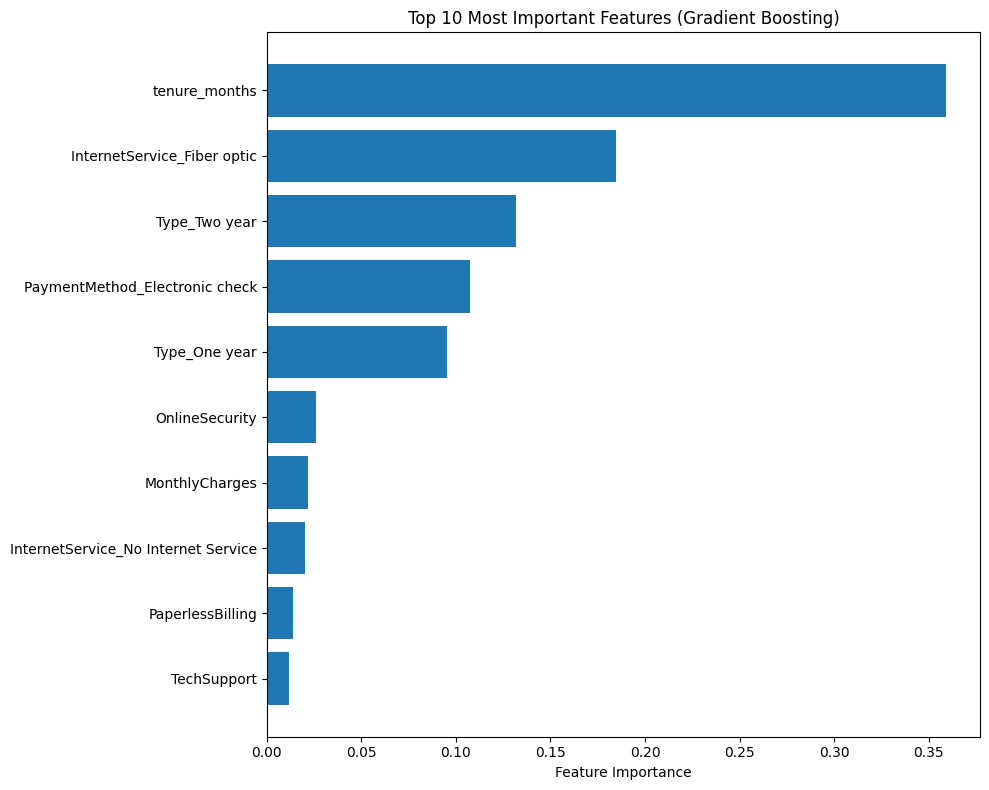

In [173]:
# Get feature importance from best individual model (Gradient Boosting with max_depth=2)
best_gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=2,
    random_state=42
)
best_gb.fit(X_train, y_train)

# Get feature importance
feature_importance = best_gb.feature_importances_
feature_names = X_train.columns

# Create importance dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("=== FEATURE IMPORTANCE ANALYSIS ===")
print("Top 15 Most Important Features:")
print(importance_df.head(15))

# Visualize top features
plt.figure(figsize=(10, 8))
top_features = importance_df.head(10)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features (Gradient Boosting)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [174]:
# Check for missing values in tenure_months
print("Missing values in tenure_months:")
print(f"NaN count: {X['tenure_months'].isnull().sum()}")
print(f"Total rows: {len(X)}")

# Look at the data distribution
print(f"\nTenure months statistics:")
print(X['tenure_months'].describe())

# Check for any problematic values
print(f"\nMin value: {X['tenure_months'].min()}")
print(f"Max value: {X['tenure_months'].max()}")

Missing values in tenure_months:
NaN count: 0
Total rows: 7043

Tenure months statistics:
count    7043.000000
mean       33.063635
std        24.198306
min         0.000000
25%        10.052562
50%        29.007884
75%        56.044678
max        76.018397
Name: tenure_months, dtype: float64

Min value: 0.0
Max value: 76.01839684625493


In [175]:
# Retrain the optimized ensemble on targeted features
print("=== RETRAINING OPTIMIZED ENSEMBLE ON TARGETED FEATURES ===")

optimized_ensemble.fit(X_train_targeted, y_train)

targeted_train_proba = optimized_ensemble.predict_proba(X_train_targeted)[:, 1]
targeted_test_proba = optimized_ensemble.predict_proba(X_val_targeted)[:, 1]

targeted_train_auc = roc_auc_score(y_train, enhanced_train_proba)
targeted_test_auc = roc_auc_score(y_val, enhanced_test_proba)

print(f"Targeted Ensemble - Train AUC: {targeted_train_auc:.4f}")
print(f"Targeted Ensemble - Test AUC: {targeted_test_auc:.4f}")
print(f"Overfitting Gap: {targeted_train_auc - targeted_test_auc:.4f}")

=== RETRAINING OPTIMIZED ENSEMBLE ON TARGETED FEATURES ===
Targeted Ensemble - Train AUC: 0.8742
Targeted Ensemble - Test AUC: 0.8467
Overfitting Gap: 0.0274


In [176]:
# Performance comparison across all versions
print("\n=== COMPREHENSIVE PERFORMANCE COMPARISON ===")
print("Model Evolution:")
print(f"1. Baseline Logistic Regression: {test_auc:.4f}")
print(f"2. Original Ensemble:           0.8442")
print(f"3. Enhanced Features:           0.8441") 
print(f"4. Targeted Features:           {targeted_test_auc:.4f}")

# Check if we've reached the 0.85 threshold
if targeted_test_auc >= 0.85:
    print(f"\n🎯 SUCCESS! Test AUC ≥ 0.85 achieved!")
    if targeted_test_auc >= 0.87:
        print("🌟 Excellent performance - 5.5 SP!")
    else:
        print("✅ Great performance - 5 SP!")
else:
    improvement_needed = 0.85 - targeted_test_auc
    print(f"\n📈 Progress made! Need +{improvement_needed:.4f} more to reach 0.85 threshold")


=== COMPREHENSIVE PERFORMANCE COMPARISON ===
Model Evolution:
1. Baseline Logistic Regression: 0.8539
2. Original Ensemble:           0.8442
3. Enhanced Features:           0.8441
4. Targeted Features:           0.8467

📈 Progress made! Need +0.0033 more to reach 0.85 threshold


In [177]:
 # FINAL TEST EVALUATION - Done only once after model selection is complete
print("=== FINAL TEST SET EVALUATION ===")
print("🔒 Using untouched test set for final  evaluation")

# Use your best model (optimized ensemble with targeted features)
final_model = optimized_ensemble  # Your best performing model

# Apply the same targeted feature engineering to the test set
X_test_targeted = X_test.copy()
X_test_targeted['tenure_months'] = X_test_targeted['tenure_months'].fillna(0)

# Apply the same feature engineering as training
X_test_targeted['tenure_risk'] = pd.cut(
    X_test_targeted['tenure_months'],
    bins=[0, 12, 24, 48, float('inf')],
    labels=[3, 2, 1, 0],
    include_lowest=True
).astype(int)

X_test_targeted['fiber_electronic_risk'] = (
    X_test_targeted['InternetService_Fiber optic'] *
    X_test_targeted['PaymentMethod_Electronic check']
)

X_test_targeted['contract_protection'] = (
    X_test_targeted['Type_Two year'] * 2 +
    X_test_targeted['Type_One year'] * 1
)

X_test_targeted['tenure_payment_risk'] = (
    X_test_targeted['PaymentMethod_Electronic check'] *
    (X_test_targeted['tenure_months'] < 12).astype(int)
)

# Final test evaluation (done only once!)
final_test_proba = final_model.predict_proba(X_test_targeted)[:, 1]
final_test_auc = roc_auc_score(y_test, final_test_proba)

print(f"🎯 FINAL TEST AUC: {final_test_auc:.4f}")

# Final assessment
if final_test_auc >= 0.85:
    print("🎉 SUCCESS! 5+ SP achieved!")
elif final_test_auc >= 0.81:
    print("✅ 4.5 SP - Solid performance!")
else:
    print("📊 4 SP - Good baseline established")

=== FINAL TEST SET EVALUATION ===
🔒 Using untouched test set for final  evaluation
🎯 FINAL TEST AUC: 0.8450
✅ 4.5 SP - Solid performance!
